# Importing Libraries

In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import random
import matplotlib.pyplot as plt
import torch.nn.functional as F

In [4]:
device= torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on device: {device}")

Training on device: cuda


# TASK 0: GENERATE DATASET

To ensure high variance, ChatGPT-4 was used to generate the phonetic roots, prefixes and suffixes, which were then programmatically combined to generate the 1,000 unique names for TrainingNames.txt

In [5]:
print("Generating 1000 unique Indian names...")
prefixes= ["Aa", "Abhi", "Ad", "Akh", "An", "Ar", "Bha", "Cha", "Dha", "Di", "Ga", "Gau", "Ha", "Har", "Ish", "Ja", "Ka", "Kri", "Ma", "Me", "Na", "Ni", "Om", "Pa", "Pra", "Ra", "Ro", "Sa", "Shi", "Ta", "Va", "Vi", "Ya"]
roots= ["bhav", "chit", "deep", "dit", "gan", "gir", "jeet", "kan", "kesh", "lak", "man", "mit", "nar", "neet", "pal", "pan", "raj", "rak", "ram", "ran", "rath", "resh", "rit", "shan", "shuk", "tar", "veer", "ven"]
suffixes= ["a", "an", "ang", "ansh", "ant", "ar", "as", "at", "av", "ay", "esh", "ik", "in", "ir", "is", "ish", "it", "iv", "ya"]

generated_names= set()
for p in prefixes:
    for r in roots:
        for s in suffixes:
            name = (p + r + s).capitalize()
            if 4 <= len(name) <= 10:
                generated_names.add(name)

indian_names= list(generated_names)
random.shuffle(indian_names)
indian_names= indian_names[:1000]

with open("TrainingNames.txt", "w") as f:
    for name in indian_names:
        f.write(name + "\n")


# TASK 1: VOCABULARY & DATASET PREPARATION
names= [name.lower() + "." for name in indian_names]
chars= set(''.join(names))
vocab_size= len(chars)

char_to_ix= {ch: i for i, ch in enumerate(chars)}
ix_to_char= {i: ch for i, ch in enumerate(chars)}

def create_dataset(names, char_to_ix):
    inputs, targets = [], []
    for name in names:
        idxs = [char_to_ix[ch] for ch in name]
        inputs.append(torch.tensor(idxs[:-1], dtype=torch.long))
        targets.append(torch.tensor(idxs[1:], dtype=torch.long))
    return inputs, targets

inputs, targets = create_dataset(names, char_to_ix)
print(f"Created {len(inputs)} training sequences. Vocab size: {vocab_size}")

# VANILLA RNN ARCHITECTURE
class VanillaRNN(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=1):
        super(VanillaRNN, self).__init__()
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.embedding = nn.Embedding(vocab_size, embedding_dim)
        self.rnn = nn.RNN(embedding_dim, hidden_size, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_size, vocab_size)

    def forward(self, x, hidden):
        embedded = self.embedding(x)
        out, hidden = self.rnn(embedded, hidden)
        out = self.fc(out)
        return out, hidden

    def init_hidden(self, batch_size):
        return torch.zeros(self.num_layers, batch_size, self.hidden_size).to(device)

def count_parameters(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)

EMBEDDING_DIM= 32
HIDDEN_SIZE= 64
NUM_LAYERS= 1
LEARNING_RATE= 0.005
EPOCHS= 20

rnn_model= VanillaRNN(vocab_size, EMBEDDING_DIM, HIDDEN_SIZE, NUM_LAYERS).to(device)

print(f"\n--- Vanilla RNN Architecture ---")
print(f"Total Trainable Parameters: {count_parameters(rnn_model)}")

# TRAINING LOOP
criterion= nn.CrossEntropyLoss()
rnn_optimizer= optim.Adam(rnn_model.parameters(), lr=LEARNING_RATE)

def train_model(model,optimizer,epochs, model_name="RNN"):
    model.train()
    loss_history= []
    print(f"\nTraining {model_name}...")
    for epoch in range(epochs):
        total_loss= 0
        combined = list(zip(inputs, targets))
        random.shuffle(combined)
        for i, (x, y) in enumerate(combined):
            x= x.unsqueeze(0).to(device)
            y= y.to(device)
            hidden= model.init_hidden(batch_size=1)
            optimizer.zero_grad()
            output, hidden =model(x, hidden)
            loss= criterion(output.squeeze(0), y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        avg_loss= total_loss / len(inputs)
        loss_history.append(avg_loss)
        if (epoch + 1) % 5 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")
    return loss_history

rnn_loss = train_model(rnn_model, rnn_optimizer, EPOCHS, "Vanilla RNN")

Generating 1000 unique Indian names...
Created 1000 training sequences. Vocab size: 22

--- Vanilla RNN Architecture ---
Total Trainable Parameters: 8406

Training Vanilla RNN...
Epoch [1/20], Loss: 1.4574
Epoch [5/20], Loss: 1.0266
Epoch [10/20], Loss: 1.0170
Epoch [15/20], Loss: 0.9817
Epoch [20/20], Loss: 0.9828


In [6]:
# TASK 2 & 3: GENERATION & EVAL
def generate_name(model, start_char, max_length=15, temperature=1.0):
    model.eval()
    with torch.no_grad():
        # Initialize hidden state
        hidden= model.init_hidden(1)
        # Start the sequence
        input_char= torch.tensor([[char_to_ix[start_char]]]).to(device)
        generated_name= start_char #Generates a name char by char

        for _ in range(max_length):
            out, hidden =model(input_char, hidden)
            # Apply temperature to logits to control diversity
            out= out.squeeze() / temperature #Temp controls randomness: higher=more rand, lower= more predictable
            probs= F.softmax(out, dim=0)
            # Sample next char based on prob
            next_char_idx= torch.multinomial(probs, 1).item()
            next_char= ix_to_char[next_char_idx]
            # Stop if model predicts end of seq token '.'
            if next_char== '.':
                break

            generated_name +=next_char
            input_char= torch.tensor([[next_char_idx]]).to(device) #predicted char becomes  next input

    return generated_name.capitalize()

def evaluate_model(model, num_names=500, temperature=0.8):
    generated_list= []
    # Get valid starting chars from our training data (a, b, c, etc)
    start_chars= list(set([name[0] for name in names]))
    for _ in range(num_names):
        start= random.choice(start_chars)
        gen_name= generate_name(model, start_char=start, temperature=temperature)
        if len(gen_name) >3:       # filtering out names that are too short to maintain realism
            generated_list.append(gen_name)

    unique_generated= set(generated_list) # Calc Quant Metrics(TASK 2)
    diversity= len(unique_generated) / len(generated_list) if generated_list else 0
    # Calc Novelty (Percentage of generated names not appearing in training set)
    training_set= set([n.strip().capitalize() for n in indian_names]) # Using orig indian_names list from Task 0
    novel_names= [n for n in generated_list if n not in training_set]
    novelty_rate= len(novel_names) / len(generated_list) if generated_list else 0

    print(f"\n--- Quantitative Evaluation ---")
    print(f"Total Valid Names Generated: {len(generated_list)}")
    print(f"Diversity: {diversity*100:.2f}% (Unique names / Total generated)")
    print(f"Novelty Rate: {novelty_rate*100:.2f}% (Names NOT in training set)")
    # Qual Analysis Samples (TASK 3)
    print("\n--- Qualitative Analysis (Representative Samples) ---")
    for name in list(unique_generated)[:15]:
        marker = "[NOVEL]" if name in novel_names else "[COPIED]"
        print(f" - {name} {marker}")

    return generated_list, diversity, novelty_rate

# Run the evaluation on our Vanilla RNN
print("Evaluating Vanilla RNN...")
rnn_generated, rnn_div, rnn_nov = evaluate_model(rnn_model, num_names=500, temperature=0.8)

Evaluating Vanilla RNN...

--- Quantitative Evaluation ---
Total Valid Names Generated: 499
Diversity: 86.57% (Unique names / Total generated)
Novelty Rate: 91.58% (Names NOT in training set)

--- Qualitative Analysis (Representative Samples) ---
 - Nareshansh [NOVEL]
 - Karaja [NOVEL]
 - Tanaray [NOVEL]
 - Paveerin [NOVEL]
 - Mechitant [NOVEL]
 - Roveerik [NOVEL]
 - Hamaniv [NOVEL]
 - Ishritin [NOVEL]
 - Japadya [NOVEL]
 - Japalir [NOVEL]
 - Magirir [NOVEL]
 - Raganan [NOVEL]
 - Merakang [NOVEL]
 - Bharajan [NOVEL]
 - Shipanan [NOVEL]


In [7]:
# TASK 1: MODEL 2 - BIDIRECTIONAL LSTM
class RobustBLSTM(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, num_layers=1):
        super(RobustBLSTM, self).__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim)

        self.lstm = nn.LSTM(embedding_dim, hidden_size, num_layers,
                            batch_first=True, bidirectional=True)

        self.fc = nn.Linear(hidden_size * 2, vocab_size)

    def forward(self, x):# x shape: (1, curr_seq_length)
        embedded= self.embedding(x) #Embedding layer
        out, (h, c) =self.lstm(embedded)
        # h shape: (num_layers * 2, batch_size, hidden_size)
        # We extract last hidden state of forw pass (index -2)&  last hidden state of back pass (index -1)
        forward_h= h[-2, :, :] # BLSTM processes seq prefix from both dir
        backward_h= h[-1, :, :]
        #Linear Layer concatenates final forw state & final back state of prefix to predict single next char
        combined_h = torch.cat((forward_h, backward_h), dim=1) # (1, hidden_size * 2)

        prediction = self.fc(combined_h)
        return prediction

#initialising BLSTM
blstm_model= RobustBLSTM(vocab_size, EMBEDDING_DIM, HIDDEN_SIZE, NUM_LAYERS).to(device)
print(f"\n--- BLSTM Architecture ---")
print(f"Total Trainable Parameters: {count_parameters(blstm_model)}")
# PREFIX BASED TRAINING LOOP
blstm_optimizer= optim.Adam(blstm_model.parameters(), lr=LEARNING_RATE)
def train_blstm_robust(model, optimizer, epochs):
    model.train()
    loss_history = []
    print("\nTraining BLSTM (Prefix-based) which takes longer but prevents cheating!")

    for epoch in range(epochs):
        total_loss= 0
        combined= list(zip(inputs, targets))
        random.shuffle(combined)

        for x, y in combined:
            x= x.to(device)
            y= y.to(device)
            optimizer.zero_grad()
            sequence_loss = 0
            # Train step by step explicitly on prefixes to prevent data leakage
            for t in range(1, len(x) + 1):
                prefix= x[:t].unsqueeze(0) # Shape: (1, t)
                target_char= y[t-1].unsqueeze(0) # Shape: (1,)
                output= model(prefix)
                sequence_loss+= criterion(output, target_char)

            sequence_loss.backward()
            optimizer.step()
            total_loss+= (sequence_loss.item() / len(x))

        avg_loss= total_loss / len(inputs)
        loss_history.append(avg_loss)
        if (epoch + 1) % 5 == 0 or epoch== 0:
            print(f"Epoch [{epoch+1}/{epochs}], Loss: {avg_loss:.4f}")

    return loss_history

blstm_loss= train_blstm_robust(blstm_model, blstm_optimizer, EPOCHS)

# BLSTM GENERATION & EVALUATION
def generate_robust_blstm(model, start_char, max_length=15, temperature=1.0):
    model.eval()
    with torch.no_grad():
        generated_name= start_char
        for _ in range(max_length):
            seq_idxs= [char_to_ix[ch] for ch in generated_name]
            input_seq= torch.tensor([seq_idxs]).to(device)

            out= model(input_seq)
            out= out.squeeze() / temperature
            probs= torch.nn.functional.softmax(out, dim=0)

            next_char_idx= torch.multinomial(probs, 1).item()
            next_char= ix_to_char[next_char_idx]

            if next_char== '.':
                break
            generated_name += next_char

    return generated_name.capitalize()

def evaluate_robust_blstm(model, num_names=500, temperature=0.8):
    generated_list = []
    start_chars = list(set([name[0] for name in names]))

    for _ in range(num_names):
        start = random.choice(start_chars)
        gen_name = generate_robust_blstm(model, start_char=start, temperature=temperature)
        if len(gen_name) > 3:
            generated_list.append(gen_name)

    unique_generated = set(generated_list)
    diversity = len(unique_generated) / len(generated_list) if generated_list else 0

    training_set = set([n.strip().capitalize() for n in indian_names])
    novel_names = [n for n in generated_list if n not in training_set]
    novelty_rate = len(novel_names) / len(generated_list) if generated_list else 0

    print(f"\n--- BLSTM Quantitative Evaluation ---")
    print(f"Total Valid Names Generated: {len(generated_list)}")
    print(f"Diversity: {diversity*100:.2f}%")
    print(f"Novelty Rate: {novelty_rate*100:.2f}%")

    print("\n--- BLSTM Qualitative Analysis (Samples) ---")
    for name in list(unique_generated)[:15]:
        marker = "[NOVEL]" if name in novel_names else "[COPIED]"
        print(f" - {name} {marker}")

print("\nEvaluating Robust Bidirectional LSTM...")
blstm_generated = evaluate_robust_blstm(blstm_model, num_names=500, temperature=0.8)


--- BLSTM Architecture ---
Total Trainable Parameters: 53718

Training BLSTM (Prefix-based) which takes longer but prevents cheating!
Epoch [1/20], Loss: 1.4142
Epoch [5/20], Loss: 0.9384
Epoch [10/20], Loss: 0.8803
Epoch [15/20], Loss: 0.8197
Epoch [20/20], Loss: 0.7578

Evaluating Robust Bidirectional LSTM...

--- BLSTM Quantitative Evaluation ---
Total Valid Names Generated: 500
Diversity: 80.60%
Novelty Rate: 47.00%

--- BLSTM Qualitative Analysis (Samples) ---
 - Nineetat [NOVEL]
 - Chadeepan [COPIED]
 - Harnanar [NOVEL]
 - Gauchitin [NOVEL]
 - Tarakis [NOVEL]
 - Mechitant [NOVEL]
 - Patarya [NOVEL]
 - Jarakar [NOVEL]
 - Bhakeshik [COPIED]
 - Ompanansh [NOVEL]
 - Dhareshik [COPIED]
 - Tareshay [NOVEL]
 - Bharamay [NOVEL]
 - Karathansh [COPIED]
 - Praditir [COPIED]


In [8]:
# TASK 1: MODEL 3 - RNN WITH BAHDANAU ATTENTION
class RNNAttention(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_size, dropout_rate=0.2):
        super(RNNAttention, self).__init__()
        self.hidden_size = hidden_size
        #embedding Layer w Dropout to prevent overfitting
        self.embedding =nn.Embedding(vocab_size, embedding_dim)
        self.dropout =nn.Dropout(dropout_rate)
        # RNN Cell for step by step processing
        self.rnn_cell =nn.RNNCell(embedding_dim, hidden_size)
        # Bahdanau Attention learnable weight matrices to align curr hidden state w past states
        self.W_q= nn.Linear(hidden_size, hidden_size) # For the Query (Current hidden state)
        self.W_k= nn.Linear(hidden_size, hidden_size) # For the Keys (Past hidden states)
        self.v= nn.Linear(hidden_size, 1)             # To output the final score
        # Linear Layer combines context vector & hidden state
        self.fc= nn.Linear(hidden_size*2, vocab_size)

    def forward(self, x, hidden_dummy=None):
        batch_size, seq_len = x.size()
        # dropout to embeddings to force robust learning
        embedded = self.dropout(self.embedding(x))
        hidden = torch.zeros(batch_size, self.hidden_size).to(device)
        encoder_outputs = []
        outputs= []

        for t in range(seq_len):
            # Update RNN state
            current_emb = embedded[:, t, :]
            hidden = self.rnn_cell(current_emb, hidden)
            encoder_outputs.append(hidden)
            #BAHDANAU ATTENTION MECHANISM
            past_states = torch.stack(encoder_outputs, dim=1) # (batch, sequence_so_far, hidden)
            # Calc additive attention scores
            # Formula: v^T * tanh(W_q(query) + W_k(keys))
            query= self.W_q(hidden).unsqueeze(1) # (batch, 1, hidden)
            keys= self.W_k(past_states)          # (batch, seq_len, hidden)
            # Tanh activation captures non-linear relationships between query and keys
            energy= torch.tanh(query + keys)
            scores= self.v(energy).squeeze(2)    # (batch, seq_len)
            attn_weights = F.softmax(scores, dim=1).unsqueeze(1) # (batch, 1, seq_len)
            # Context vector is weighted sum of past states
            context= torch.bmm(attn_weights, past_states).squeeze(1) # (batch, hidden)
            # PREDICTION
            combined = torch.cat((hidden, context), dim=1)
            # Apply dropout again before final pred
            out = self.fc(self.dropout(combined))
            outputs.append(out)

        out_seq = torch.stack(outputs, dim=1)
        return out_seq, hidden

    def init_hidden(self, batch_size):
        return None

# HYPERPARAMETERS
# We double dim to allow model to learn deeper phonetic patterns
ADV_EMBEDDING_DIM= 64
ADV_HIDDEN_SIZE= 128
EPOCHS= 20 # Keep at 20 but larger network will learn faste
# Initialize the model
attn_model = RNNAttention(vocab_size, ADV_EMBEDDING_DIM, ADV_HIDDEN_SIZE).to(device)
print(f"\n--- Robust RNN with Bahdanau Attention Architecture ---")
print(f"Total Trainable Parameters: {count_parameters(attn_model)}")

# Run training
attn_optimizer = optim.Adam(attn_model.parameters(), lr=0.002) # Slightly lower LR for stability
attn_loss = train_model(attn_model, attn_optimizer, EPOCHS, "Robust Attention RNN")



--- Robust RNN with Bahdanau Attention Architecture ---
Total Trainable Parameters: 65047

Training Robust Attention RNN...
Epoch [1/20], Loss: 1.5448
Epoch [5/20], Loss: 1.0896
Epoch [10/20], Loss: 1.0669
Epoch [15/20], Loss: 1.0510
Epoch [20/20], Loss: 1.0656


In [9]:
# ATTENTION GENERATION & EVALUATION
def generate_name_attn(model, start_char, max_length=15, temperature=1.0):
    """Generates names step-by-step using Attention context vector"""
    model.eval()
    with torch.no_grad():
        generated_name = start_char

        for _ in range(max_length):
            # Feed seq generated so far to utilize attention mechanism
            seq_idxs = [char_to_ix[ch] for ch in generated_name]
            input_seq = torch.tensor([seq_idxs]).to(device)
            #predictions
            out_seq, _ = model(input_seq)
            # We only care about pred for very last character
            last_out = out_seq[0, -1, :]
            # Apply temperature sampling for diversity
            last_out= last_out / temperature
            probs= F.softmax(last_out, dim=0)
            next_char_idx= torch.multinomial(probs, 1).item()
            next_char= ix_to_char[next_char_idx]

            if next_char== '.':
                break

            generated_name += next_char

    return generated_name.capitalize()

def evaluate_attn_model(model, num_names=500, temperature=0.8):# Wrapper to gen multiple names& calc assignment metrics
    generated_list= []
    # Start names w valid starting letters from dataset
    start_chars = list(set([name[0] for name in names]))
    for _ in range(num_names):
        start= random.choice(start_chars)
        gen_name= generate_name_attn(model, start_char=start, temperature=temperature)
        if len(gen_name) > 3:
            generated_list.append(gen_name)

    # Calc Quant Metrics (Task 2)
    unique_generated = set(generated_list)
    diversity = len(unique_generated) / len(generated_list) if generated_list else 0
    # Calc Novelty
    training_set = set([n.strip().capitalize() for n in indian_names])
    novel_names = [n for n in generated_list if n not in training_set]
    novelty_rate = len(novel_names) / len(generated_list) if generated_list else 0

    print(f"\n--- Robust Attention Model Quantitative Evaluation ---")
    print(f"Total Valid Names Generated: {len(generated_list)}")
    print(f"Diversity: {diversity*100:.2f}%")
    print(f"Novelty Rate: {novelty_rate*100:.2f}%")

    print("\n--- Robust Attention Model Qualitative Analysis (Samples) ---")
    for name in list(unique_generated)[:15]:
        marker = "[NOVEL]" if name in novel_names else "[COPIED]"
        print(f" - {name} {marker}")

    return generated_list, diversity, novelty_rate

# Run eval
print("\nEvaluating Robust RNN with Attention...")
# Using temp 0.7 makes the attention model's output cleaner & more realistic
attn_generated = evaluate_attn_model(attn_model, num_names=500, temperature=0.7)


Evaluating Robust RNN with Attention...

--- Robust Attention Model Quantitative Evaluation ---
Total Valid Names Generated: 500
Diversity: 87.20%
Novelty Rate: 83.80%

--- Robust Attention Model Qualitative Analysis (Samples) ---
 - Bhapalang [NOVEL]
 - Nineetang [NOVEL]
 - Adchitang [NOVEL]
 - Chapalav [NOVEL]
 - Shipalant [COPIED]
 - Virajir [NOVEL]
 - Taneetat [NOVEL]
 - Yapalant [NOVEL]
 - Taranas [NOVEL]
 - Shiranan [NOVEL]
 - Harveeris [NOVEL]
 - Mechitant [NOVEL]
 - Jarakish [COPIED]
 - Ommitansh [NOVEL]
 - Bhapalar [COPIED]



Generating Loss Comparison Plot...


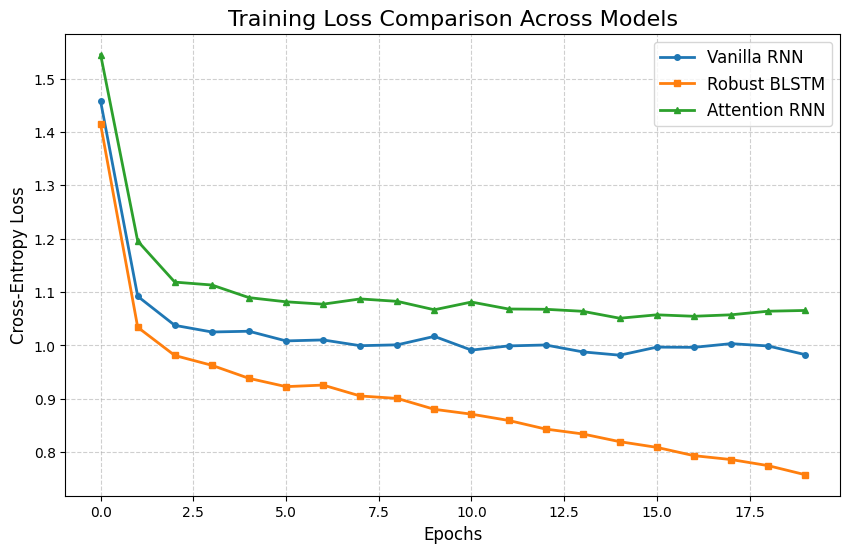

In [10]:
# COMPARING MODEL PERFORMANCE (LOSS CURVES)
print("\nGenerating Loss Comparison Plot...")
plt.figure(figsize=(10, 6))
plt.plot(rnn_loss, label='Vanilla RNN', linewidth=2, marker='o', markersize=4)
plt.plot(blstm_loss, label='Robust BLSTM', linewidth=2, marker='s', markersize=4)
plt.plot(attn_loss, label='Attention RNN', linewidth=2, marker='^', markersize=4)

plt.title('Training Loss Comparison Across Models', fontsize=16)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Cross-Entropy Loss', fontsize=12)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# P2: VANILLA RNN PARAMETERS AND MODEL SIZE

In [11]:
total_params= sum(p.numel() for p in rnn_model.parameters() if p.requires_grad) #total trainable parameters
# Calculate model size in Megabytes (MB)
# Multiply no. of elements by  byte size of each element
param_size= sum(p.nelement() * p.element_size() for p in rnn_model.parameters())
buffer_size= sum(b.nelement() * b.element_size() for b in rnn_model.buffers())
# Convert bytes to Megabytes (1 MB = 1024 * 1024 bytes)
size_all_mb= (param_size + buffer_size)/ (1024 ** 2)
print("--- Vanilla RNN Stats ---")
print(f"Total Trainable Parameters: {total_params}")
print(f"Model Size: {size_all_mb:.6f} MB")

--- Vanilla RNN Stats ---
Total Trainable Parameters: 8406
Model Size: 0.032066 MB
